# scPoli校正流程 Python版

把`原始基因表达h5ad`和`cell×10 scPoli h5ad`合并，按Seurat代码逻辑做epithelial subset、Normalize、UMAP过滤、scPoli聚类、local purity过滤、marker DotPlot和统计输出。

该文件的输出都在：/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_mouse_scpoli

# import

In [1]:
import anndata
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
sc.settings.verbosity=2
sc.settings.seed=1234
np.random.seed(1234)

In [ ]:
raw_h5ad="../../7_mapping_new_data/0521_no_Basophil/output_mouse/Mouse_allgene_annot_counts.h5ad"##只有小鼠数据 原始counts + annot,现在这个文件中的cell_type_level1是ground truth
scpoli_h5ad="../../7_mapping_new_data/0521_no_Basophil/output_mouse/Mouse-aggred-normalized-hvg-integrated-nogene.h5ad"### all human scpoli data without gene names, but with annotation
outdir="./output_mouse/"
counts_layer="rounded_corrected_counts"
original_celltype_col="cell_type_level1"##原始文件里的标签
os.makedirs(outdir,exist_ok=True)

In [3]:
#####读取文件 按 adata_scpoli 的细胞ID 对齐 adata_raw
adata_raw=sc.read_h5ad(raw_h5ad)
adata_scpoli=sc.read_h5ad(scpoli_h5ad)
print(adata_raw)
print(adata_raw.obs_names)
print(adata_scpoli)
print(adata_scpoli.obs_names)

AnnData object with n_obs × n_vars = 572085 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE131776_5_UMAP', 'decontX_GSE131776_6_UMAP', 'decontX_GSE131776_7_UMAP', 'decontX_GSE131776_8_UMAP', 'decontX_GSE131776_9_UMAP', 'decontX_GSE141031_apoe

In [4]:
###得到共同的细胞
adata_raw.obs_names=adata_raw.obs_names.astype(str)
adata_scpoli.obs_names=adata_scpoli.obs_names.astype(str)
##保留原始barcode
adata_raw.obs["barcode_for_match"]=adata_raw.obs_names
adata_scpoli.obs["barcode_for_match"]=adata_scpoli.obs_names.str[:-2]
##用 sample + barcode 构建唯一ID
adata_raw.obs["match_id"]=adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
adata_scpoli.obs["match_id"]=adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
##如果sample仍不唯一，就改成 dataset + sample + barcode
if adata_raw.obs["match_id"].duplicated().sum()>0 or adata_scpoli.obs["match_id"].duplicated().sum()>0:
    adata_raw.obs["match_id"]=adata_raw.obs["dataset"].astype(str)+"__"+adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
    adata_scpoli.obs["match_id"]=adata_scpoli.obs["dataset"].astype(str)+"__"+adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
print("raw duplicated match_id:",adata_raw.obs["match_id"].duplicated().sum())
print("scpoli duplicated match_id:",adata_scpoli.obs["match_id"].duplicated().sum())
if adata_raw.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_raw match_id仍有重复，不能安全匹配")
if adata_scpoli.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_scpoli match_id仍有重复，不能安全匹配")
adata_raw.obs_names=adata_raw.obs["match_id"].astype(str)
adata_scpoli.obs_names=adata_scpoli.obs["match_id"].astype(str)

##空值填充为query
if "atlas_key" not in adata_scpoli.obs:
    adata_scpoli.obs["atlas_key"]="query"
else:
    adata_scpoli.obs["atlas_key"]=adata_scpoli.obs["atlas_key"].astype("object")
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].isna(),"atlas_key"]="query"
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].astype(str).isin(["","nan","None","NA"]),"atlas_key"]="query"

print(adata_scpoli.obs["atlas_key"].value_counts(dropna=False))
##以 scpoli 为准，从 raw 中取相同细胞
scp_ids=adata_scpoli.obs_names
missing=scp_ids[~scp_ids.isin(adata_raw.obs_names)]
print("scpoli cells:",len(scp_ids))
print("missing in raw:",len(missing))
if len(missing)>0:
    print(missing[:50].tolist())
    raise ValueError("有 scpoli 细胞在 raw 中找不到")
adata=adata_raw[scp_ids,:].copy()
adata_com_scpoli=adata_scpoli.copy()
assert np.all(adata.obs_names==adata_com_scpoli.obs_names)
print("aligned adata:",adata)
print("aligned adata_com_scpoli:",adata_com_scpoli)

raw duplicated match_id: 0
scpoli duplicated match_id: 0
atlas_key
query    566264
Name: count, dtype: int64
scpoli cells: 566264
missing in raw: 0
aligned adata: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UM

In [ ]:
# adata_query = adata[adata.obs['atlas_key'] == 'query']
# adata_query.obs['cell_type_level1'].value_counts()

In [ ]:
# adata.obs['atlas_key'].value_counts()

In [5]:
adata_com_scpoli.write(os.path.join(outdir, "mouse_scpoli_com.h5ad"))
adata.write(os.path.join(outdir, "mouse_raw_com.h5ad"))

In [6]:
adata_com_scpoli

AnnData object with n_obs × n_vars = 566264 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'location', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human(measure)&mouse', 'barcode_for_match', 'match_id'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [7]:
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id'
    var: 'original_gene_names'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE131776_5_UMAP', 'decontX_GSE131776_6_UMAP', 'decontX_GSE131776_7_UMAP', 'decontX_GSE131776_8_UMAP', 'decontX_GSE131776

In [8]:
##选择原始 counts 矩阵，并检查它像不像真正的原始计数
if counts_layer in adata.layers:
    adata.X=adata.layers[counts_layer].copy()
    print("use layer:",counts_layer)
else:
    print("layer not found,use adata.X:",counts_layer)
adata.layers["counts"]=adata.X.copy()
x=adata.layers["counts"]
v=x.data if sp.issparse(x) else np.ravel(x)
v=v[:min(len(v),1000000)]
print("counts min",np.min(v),"max",np.max(v),"integer-like",np.allclose(v,np.round(v)))

layer not found,use adata.X: rounded_corrected_counts
counts min 1 max 18798 integer-like True


In [9]:
#####添加需要的obs
run_tag="precorrect"
for c in ["leiden","cell_type_pred","cell_type_uncert","query","cell_type_pred_ref","cell_type_level1_human","atlas_key"]:
    if c in adata_com_scpoli.obs:
        adata.obs[c]=adata_com_scpoli.obs[c].values
        print("+obs",c)
X=adata_com_scpoli.X.toarray() if sp.issparse(adata_com_scpoli.X) else np.asarray(adata_com_scpoli.X)
adata.obsm["X_scPoli"]=X
if "X_umap" in adata_com_scpoli.obsm:
    adata.obsm["X_umap"]=np.asarray(adata_com_scpoli.obsm["X_umap"])
print("X_scPoli",adata.obsm["X_scPoli"].shape)
print("X_umap",adata.obsm["X_umap"].shape if "X_umap" in adata.obsm else None)
adata.write(os.path.join(outdir,f"mouse_raw_counts_scpoli_{run_tag}.h5ad"))

+obs leiden
+obs cell_type_pred
+obs cell_type_uncert
+obs query
+obs cell_type_pred_ref
+obs atlas_key
X_scPoli (566264, 10)
X_umap (566264, 2)


In [10]:
##先画一张全体细胞的 UMAP，检查 cell_type_pred 是否正常
if "X_umap" in adata.obsm and "cell_type_pred" in adata.obs:
    sc.pl.umap(adata,color="cell_type_pred",legend_loc="on data",frameon=False,size=1,show=False)
    plt.savefig(os.path.join(outdir,"umap_cell_type_pred_full.pdf"),bbox_inches="tight")
    plt.close()
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors'
    obsm: 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'deco

In [11]:
adata.obs['cell_type_level1'].value_counts()

cell_type_level1
Fibroblast               124007
Smooth muscle cell       121970
Macrophage                90303
T cell                    76450
Neutrophil                46488
B cell                    29164
Endothelial cell          26905
Dendritic cell            18800
Monocyte                  14137
Erythrocyte/Erythroid     10232
Natural killer cell        5947
Pericyte                   1671
Mast cell                   190
Name: count, dtype: int64

# mac/mono/neu

In [3]:
outdir="./output_mouse/"
adata = sc.read_h5ad(os.path.join(outdir,f"mouse_raw_counts_scpoli_precorrect.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE1317

In [10]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/mac_mono_neu/"

In [5]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [6]:
mac_mono_neu = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Macrophage", "Monocyte", "Neutrophil"],
    outdir=outdir,
    prefix="mac_mono_neu",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Macrophage', 'Monocyte', 'Neutrophil']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UM

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:02)
lognorm min 0.22429447 max 9.210441 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Macrophage    90303
Neutrophil    46488
Monocyte      14137
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 150928 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
   

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/mac_mono_neu/umap_mac_mono_neu_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/mac_mono_neu/umap_mac_mono_neu_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/mac_mono_neu/umap_mac_mono_neu_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     5307
1     5168
2     5164
3     4934
4     4923
5     4902
6     4619
7     4579
8     4557
9     4394
10    4286
11    4267
12    4126
13    4120
14    3992
15    3954
16    3906
17    3538
18    3522
19    3339
20    3333
21    3305
22    3300
23    3127
24    3121
25    3045
26    2974
27    2956
28    2947
29    2945
30    2764
31    2744
32    2516
33    2505
34    2461
35    2457
36    2399
37    2386
38    2318
39    2029
40    2011
41    1833
42    1485
43    1278
44    1092
Name: count, dtype: int64
Saved to: ./output_mouse/mac_mono_neu/mac_mono_neu_scPoli_recluster_umap.h5ad


In [11]:
work = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 150928 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131

In [14]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
#     'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
#     'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
#     'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
#     'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
#     'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
#     'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
#     'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
#     # 'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
#     'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
#     'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
# }
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [15]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "mac_mono_neu_cluster_correction_summary.csv"))

         major_pred  major_pred_frac      major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                               
0          Monocyte         0.962502          Monocyte           0.722630     5307            Monocyte
1        Neutrophil         0.536765        Neutrophil           0.884675     5168          Neutrophil
2        Macrophage         0.997870        Macrophage           0.542603     5164          Macrophage
3        Macrophage         0.999392        Macrophage           0.756182     4934          Macrophage
4        Macrophage         0.979890          Pericyte           0.617103     4923           Uncertain
5          Monocyte         0.556304          Monocyte           0.614239     4902           Uncertain
6        Macrophage         1.000000          Pericyte           0.556181     4619           Uncertain
7        Neutrophil         1.000000        Fibroblast           0.332387

In [16]:
corrected_annotation = {
    "4": "Macrophage",
    "5": "Monocyte",
    "6": "Macrophage",
    "7": "Macrophage",
    "11": "Macrophage",
    "12": "Macrophage",
    "17": "Macrophage",
    "20": "Macrophage",
    "22": "Macrophage",
    "23": "Macrophage",
    "25": "Macrophage",
    "26": "Macrophage",
    "30": "Macrophage",
    "33": "Dendritic cell",
    "35": "Dendritic cell",
    "36": "Dendritic cell",
    "37": "Dendritic cell",
    "38": "Macrophage",
    "42": "Macrophage",
    "43": "Endothelial cell",
    "44": "Endothelial cell"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Macrophage          113145
Neutrophil           15457
Monocyte             10209
Dendritic cell        9747
Endothelial cell      2370
Name: count, dtype: int64


In [17]:
work.write_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))

In [110]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cell_type_level1_corrected4.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_dataset_after_correction4.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_corrected4.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

In [111]:
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Macrophage          113145
Neutrophil           15457
Monocyte             10209
Dendritic cell        9747
Endothelial cell      2370
Name: count, dtype: int64


# DC

In [113]:
outdir="./output_mouse/"
adata = sc.read_h5ad(os.path.join(outdir,f"mouse_raw_counts_scpoli_precorrect.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE1317

In [46]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/dc/"

In [115]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [116]:
dc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Dendritic cell"],
    outdir=outdir,
    prefix="dc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Dendritic cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE13177

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:04)
lognorm min 0.225672 max 9.076923 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Dendritic cell    18800
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 18800 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scPoli', 'X_

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/dc/umap_dc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/dc/umap_dc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/dc/umap_dc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     956
1     840
2     773
3     747
4     746
5     705
6     690
7     665
8     653
9     652
10    615
11    600
12    546
13    536
14    534
15    527
16    505
17    497
18    458
19    456
20    452
21    442
22    426
23    417
24    417
25    398
26    391
27    386
28    382
29    372
30    365
31    308
32    304
33    295
34    240
35    239
36    140
37    125
Name: count, dtype: int64
Saved to: ./output_mouse/dc/dc_scPoli_recluster_umap.h5ad


In [47]:
work = sc.read_h5ad(os.path.join(outdir, "dc_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 18800 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [48]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
#     'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
#     'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
#     'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
#     'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
#     'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
#     'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
#     'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
#     'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
#     'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
#     'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
# }
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_dc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_dc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [49]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "dc_cluster_correction_summary.csv"))

             major_pred  major_pred_frac    major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                 
0        Dendritic cell              1.0  Dendritic cell           0.955021      956      Dendritic cell
1        Dendritic cell              1.0  Dendritic cell           0.555952      840      Dendritic cell
2        Dendritic cell              1.0  Dendritic cell           0.667529      773      Dendritic cell
3        Dendritic cell              1.0  Dendritic cell           0.416332      747      Dendritic cell
4        Dendritic cell              1.0  Dendritic cell           0.416890      746      Dendritic cell
5        Dendritic cell              1.0  Dendritic cell           0.987234      705      Dendritic cell
6        Dendritic cell              1.0  Dendritic cell           0.821739      690      Dendritic cell
7        Dendritic cell              1.0  Dendritic cel

In [50]:
corrected_annotation = {
    "0": "Dendritic cell",
    "1": "Dendritic cell",
    "2": "Dendritic cell",
    "3": "Dendritic cell",
    "4": "Dendritic cell",
    "5": "Dendritic cell",
    "6": "Dendritic cell",
    "7": "Dendritic cell",
    "8": "Dendritic cell",
    "9": "Dendritic cell",
    "10": "Dendritic cell",
    "11": "Dendritic cell",
    "12": "Dendritic cell",
    "13": "Monocyte",
    "14": "Dendritic cell",
    "15": "Dendritic cell",
    "16": "Dendritic cell",
    "17": "Monocyte",
    "18": "Dendritic cell",
    "19": "Dendritic cell",
    "20": "Dendritic cell",
    "21": "Dendritic cell",
    "22": "Monocyte",
    "23": "Dendritic cell",
    "24": "Dendritic cell",
    "25": "Dendritic cell",
    "26": "Dendritic cell",
    "27": "Dendritic cell",
    "28": "Dendritic cell",
    "29": "Dendritic cell",
    "30": "Dendritic cell",
    "31": "Monocyte",
    "32": "Monocyte",
    "33": "Dendritic cell",
    "34": "Dendritic cell",
    "35": "Dendritic cell",
    "36": "Dendritic cell",
    "37": "Dendritic cell"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Dendritic cell    16729
Monocyte           2071
Name: count, dtype: int64


In [51]:
work.write_h5ad(os.path.join(outdir, "dc_scPoli_recluster_umap_corrected.h5ad"))

In [52]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_dc_cell_type_level1_corrected4.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_dc_dataset_after_correction4.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_dc_by_corrected4.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_dc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# smc/fibro

In [ ]:
# outdir="./output_mouse/"
# adata = sc.read_h5ad(os.path.join(outdir,f"mouse_raw_counts_scpoli_precorrect.h5ad"))
# adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE1317

In [21]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/smc_fibro"

In [8]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [9]:
smc_fibro = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Smooth muscle cell", "Fibroblast"],
    outdir=outdir,
    prefix="smc_fibro",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Smooth muscle cell', 'Fibroblast']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:25)
lognorm min 0.24512246 max 8.590616 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Fibroblast            124007
Smooth muscle cell    121970
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 245977 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    u

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/smc_fibro/umap_smc_fibro_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/smc_fibro/umap_smc_fibro_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/smc_fibro/umap_smc_fibro_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     7531
1     7239
2     7204
3     6827
4     6799
5     6729
6     6726
7     6678
8     6622
9     6603
10    6503
11    6156
12    5877
13    5843
14    5747
15    5581
16    5555
17    5505
18    5239
19    5105
20    5097
21    5085
22    4942
23    4893
24    4887
25    4842
26    4672
27    4657
28    4638
29    4477
30    4246
31    4174
32    4168
33    4150
34    4066
35    3839
36    3794
37    3575
38    3526
39    3474
40    3343
41    3104
42    3036
43    2958
44    2947
45    2834
46    2468
47    2341
48    2323
49    1902
50    1734
51    1629
52    1189
53     898
Name: count, dtype: int64
Saved to: ./output_mouse/smc_fibro/smc_fibro_scPoli_recluster_umap.h5ad


In [22]:
work = sc.read_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 245977 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131

In [23]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
    # 'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
    # 'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    # 'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
    # 'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
    # 'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
    # 'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
    # 'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
    # 'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
    # 'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
    # 'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
    # 'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    # 'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
    # 'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    # 'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
#     'Pericyte_2': ['Notch3', 'Pdgfrb', 'Rgs5', 'Cspg4', 'Kcnj8', 'Abcc9'],
# }

marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}


marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [24]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "smc_fibro_cluster_correction_summary.csv"))

                 major_pred  major_pred_frac        major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                         
0                Fibroblast         1.000000          Fibroblast           0.883017     7531          Fibroblast
1                Fibroblast         0.558503  Smooth muscle cell           0.689045     7239           Uncertain
2        Smooth muscle cell         1.000000  Smooth muscle cell           0.997363     7204  Smooth muscle cell
3                Fibroblast         1.000000          Fibroblast           0.990186     6827          Fibroblast
4        Smooth muscle cell         1.000000  Smooth muscle cell           0.997500     6799  Smooth muscle cell
5                Fibroblast         1.000000          Fibroblast           0.978600     6729          Fibroblast
6                Fibroblast         1.000000          Fibroblast           0.991079     6726    

In [29]:
corrected_annotation = {
    "1": "Smooth muscle cell",
    "25": "Smooth muscle cell",
    "31": "Fibroblast",
    "43": "Fibroblast",
    "45": "Fibroblast",
    "50": "Fibroblast",
    "53": "Fibroblast",
    
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Smooth muscle cell    127848
Fibroblast            118129
Name: count, dtype: int64


In [30]:
work.write_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap_corrected.h5ad"))

In [31]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_smc_fib_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_smc_fib_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_smc_fib_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# T cell

In [ ]:
# adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
# adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [32]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/tc"

In [11]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [12]:
tc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["T cell"],
    outdir=outdir,
    prefix="tc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['T cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:01)
lognorm min 0.22213812 max 8.075671 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
T cell    76450
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 76450 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scPoli', 'X_umap',

    finished (0:03:07)
running Leiden clustering
    finished (0:33:00)
computing UMAP
    finished (0:04:02)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/tc/umap_tc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/tc/umap_tc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/tc/umap_tc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     3510
1     3148
2     3031
3     2912
4     2814
5     2761
6     2605
7     2599
8     2592
9     2458
10    2362
11    2360
12    2313
13    2281
14    2212
15    2142
16    2102
17    2068
18    2021
19    1977
20    1975
21    1958
22    1811
23    1768
24    1670
25    1515
26    1513
27    1504
28    1480
29    1428
30    1410
31    1386
32    1296
33    1121
34    1058
35     888
36     886
37     839
38     676
Name: count, dtype: int64
Saved to: ./output_mouse/tc/tc_scPoli_recluster_umap.h5ad


In [33]:
work = sc.read_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 76450 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [34]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
#     'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
#     'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
#     'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
#     'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
#     'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
#     'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
#     'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
#     'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
#     'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
#     'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
# }

marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}



marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [35]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "tc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           T cell              1.0       T cell           0.999715     3510              T cell
1           T cell              1.0       T cell           0.998729     3148              T cell
2           T cell              1.0       T cell           0.999670     3031              T cell
3           T cell              1.0       T cell           0.965316     2912              T cell
4           T cell              1.0       T cell           0.957001     2814              T cell
5           T cell              1.0       T cell           0.979717     2761              T cell
6           T cell              1.0       T cell           0.986948     2605              T cell
7           T cell              1.0       T cell           0.909965     2599              T cell
8           T cell            

In [41]:
corrected_annotation = {
    "17" : "T cell",
    "38" : "T cell"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
T cell    76450
Name: count, dtype: int64


In [42]:
work.write_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap_corrected.h5ad"))

In [43]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_tc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_tc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_tc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_tc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# ECs

In [44]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/ec"

In [14]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [15]:
ec = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Endothelial cell"],
    outdir=outdir,
    prefix="ec",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Endothelial cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:02)
lognorm min 0.35060126 max 8.594593 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Endothelial cell    26905
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 26905 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scPoli',

    finished (0:01:00)
running Leiden clustering
    finished (0:05:42)
computing UMAP
    finished (0:01:01)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/ec/umap_ec_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/ec/umap_ec_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/ec/umap_ec_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1272
1     1252
2     1183
3     1163
4     1098
5     1092
6     1053
7      965
8      960
9      922
10     887
11     871
12     864
13     862
14     854
15     808
16     793
17     768
18     763
19     754
20     720
21     706
22     687
23     655
24     606
25     543
26     540
27     524
28     491
29     455
30     429
31     424
32     391
33     319
34     179
35      52
Name: count, dtype: int64
Saved to: ./output_mouse/ec/ec_scPoli_recluster_umap.h5ad


In [45]:
work = sc.read_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 26905 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [46]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
#     'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
#     'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
#     'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
#     'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
#     'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
#     'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
#     'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
#     'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
#     'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
#     'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
# }

marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}


marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [47]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "ec_cluster_correction_summary.csv"))

               major_pred  major_pred_frac      major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                     
0        Endothelial cell              1.0  Endothelial cell           0.881289     1272    Endothelial cell
1        Endothelial cell              1.0  Endothelial cell           0.957668     1252    Endothelial cell
2        Endothelial cell              1.0  Endothelial cell           0.975486     1183    Endothelial cell
3        Endothelial cell              1.0  Endothelial cell           0.989682     1163    Endothelial cell
4        Endothelial cell              1.0  Endothelial cell           0.618397     1098    Endothelial cell
5        Endothelial cell              1.0  Endothelial cell           0.990842     1092    Endothelial cell
6        Endothelial cell              1.0  Endothelial cell           0.995252     1053    Endothelial cell
7        Endothelia

In [50]:
corrected_annotation = {
        "24" : "Endothelial cell",
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Endothelial cell    26905
Name: count, dtype: int64


In [51]:
work.write_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap_corrected.h5ad"))

In [52]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_ec_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_ec_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_ec_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_ec_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# NK

In [53]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/nk"

In [17]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [18]:
nk = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Natural killer cell"],
    outdir=outdir,
    prefix="nk",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Natural killer cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE

    finished (0:00:23)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/nk/umap_nk_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/nk/umap_nk_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/nk/umap_nk_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     342
1     326
2     319
3     283
4     274
5     266
6     265
7     246
8     244
9     243
10    242
11    242
12    239
13    238
14    234
15    208
16    202
17    191
18    182
19    151
20    149
21    144
22    134
23    121
24    115
25    112
26    101
27     79
28     55
Name: count, dtype: int64
Saved to: ./output_mouse/nk/nk_scPoli_recluster_umap.h5ad


In [54]:
work = sc.read_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 5947 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE13177

In [55]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
#     'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
#     'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
#     'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
#     'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
#     'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
#     'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
#     'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
#     'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
#     'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
#     'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
# }
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}


marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [56]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "nk_cluster_correction_summary.csv"))

                  major_pred  major_pred_frac         major_marker  major_marker_frac  n_cells  cluster_label_clean
cluster                                                                                                            
0        Natural killer cell              1.0               T cell           0.830409      342            Uncertain
1        Natural killer cell              1.0  Natural killer cell           0.947853      326  Natural killer cell
2        Natural killer cell              1.0  Natural killer cell           0.783699      319  Natural killer cell
3        Natural killer cell              1.0  Natural killer cell           0.766784      283  Natural killer cell
4        Natural killer cell              1.0               T cell           0.886861      274            Uncertain
5        Natural killer cell              1.0  Natural killer cell           0.936090      266  Natural killer cell
6        Natural killer cell              1.0               T cell      

In [57]:
corrected_annotation = {
    "0": "T cell",
    "4": "T cell",
    "6": "T cell",
    "12": "T cell",
    "17": "T cell",
    "18": "T cell",
    "22": "T cell",
    "26": "T cell",
    "28": "T cell"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Natural killer cell    4164
T cell                 1783
Name: count, dtype: int64


In [58]:
work.write_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap_corrected.h5ad"))

In [59]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_nk_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_nk_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_nk_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_nk_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bo

# B cells

In [62]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/bc"

In [20]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [21]:
bc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["B cell"],
    outdir=outdir,
    prefix="bc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['B cell']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:01)
lognorm min 0.18052614 max 8.686839 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
B cell    29164
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 29164 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scPoli', 'X_umap',

    finished (0:01:07)
running Leiden clustering
    finished (0:08:42)
computing UMAP
    finished (0:01:06)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/bc/umap_bc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/bc/umap_bc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/bc/umap_bc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1197
1     1188
2     1094
3     1053
4     1018
5      991
6      984
7      982
8      975
9      946
10     936
11     907
12     897
13     883
14     880
15     858
16     857
17     829
18     808
19     807
20     806
21     793
22     764
23     744
24     739
25     703
26     693
27     680
28     647
29     625
30     592
31     517
32     512
33     485
34     432
35     342
Name: count, dtype: int64
Saved to: ./output_mouse/bc/bc_scPoli_recluster_umap.h5ad


In [66]:
work = sc.read_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 29164 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [67]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
#     'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
#     'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
#     'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
#     'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
#     'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
#     'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
#     'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
#     'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
#     'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
#     'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
# }

marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}


marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [68]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "bc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           B cell              1.0       B cell           0.955723     1197              B cell
1           B cell              1.0       B cell           0.611953     1188              B cell
2           B cell              1.0       B cell           0.972578     1094              B cell
3           B cell              1.0       B cell           0.980057     1053              B cell
4           B cell              1.0       B cell           0.905697     1018              B cell
5           B cell              1.0       B cell           0.967709      991              B cell
6           B cell              1.0       B cell           0.936992      984              B cell
7           B cell              1.0       B cell           0.950102      982              B cell
8           B cell            

In [72]:
corrected_annotation = {
    "33": "B cell"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
B cell    29164
Name: count, dtype: int64


In [73]:
work.write_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap_corrected.h5ad"))

In [74]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_bc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_bc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_bc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_bc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# Erythroid 

In [75]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_mouse/Erythroid"

In [23]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [24]:
outdir="./output_mouse/Erythroid"
Erythroid = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Erythrocyte/Erythroid"],
    outdir=outdir,
    prefix="Erythroid",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Erythrocyte/Erythroid']
Original object: AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_G

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:00)
lognorm min 0.19870238 max 9.210441 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Erythrocyte/Erythroid    10232
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 10232 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    uns: 'log1p'
    obsm: 'X_scP

    finished (0:00:37)
computing UMAP
    finished (0:00:19)


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/Erythroid/umap_Erythroid_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/Erythroid/umap_Erythroid_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_mouse/Erythroid/umap_Erythroid_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     669
1     623
2     621
3     513
4     498
5     456
6     455
7     450
8     417
9     392
10    357
11    347
12    332
13    328
14    327
15    326
16    313
17    304
18    294
19    281
20    267
21    264
22    255
23    243
24    228
25    223
26    193
27    168
28     88
Name: count, dtype: int64
Saved to: ./output_mouse/Erythroid/Erythroid_scPoli_recluster_umap.h5ad


In [76]:
work = sc.read_h5ad(os.path.join(outdir, "Erythroid_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 10232 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3'
    var: 'original_gene_names'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE1317

In [77]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
# marker_dict = {
#     'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2'],
#     'T cell': ['Cd2', 'Trac', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'Natural killer cell': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl2', 'Cd160', 'Fcgr3', 'Prf1', 'Gnly'],
#     'Dendritic cell': ['Clec10a', 'Fcer1a', 'Cd1d1', 'H2-Ab1', 'H2-Eb1'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Cxcl8', 'Aif1', 'Cd68', 'Itgam', 'Csf1r', 'H2-Ab1', 'Lgals3', 'Cd163'],
#     'Monocyte': ['Fcn1', 'S100a8', 'S100a9', 'S100a12', 'Vcan', 'Cd52', 'Lyz2', 'Ctss', 'Cd14'],
#     'Mast cell': ['Tpsab1', 'Tpsb2', 'Hdc', 'Cma1'],
#     'Erythrocyte/Erythroid': ['Hbb-bs', 'Hba-a1', 'Hba-a2', 'Alas2', 'Ahsp', 'Slc4a1', 'Gypa', 'Klf1', 'Tmcc2'],
#     'Neutrophil': ['Nampt', 'Ifitm2', 'G0s2', 'Cxcl8', 'Neat1', 'Srgn', 'Aqp9', 'Sod2', 'Fcgr3', 'Ivns1abp'],
#     'Basophil': ['Tpsb2', 'Cpa3', 'Slc24a3', 'Fer', 'Kit', 'Hpgds', 'Sytl3', 'Maml3', 'Ell2', 'Ccac200', 'Akap13', 'Areg', 'Rhoh', 'Lrmda', 'Arid1b', 'Irak3', 'Tex14', 'Hpgd', 'Ercc1', 'Ctnnbl1', 'Zbtb20'],
#     'Endothelial cell': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Ifi27l2a', 'Ecscr', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1'],
#     'Smooth muscle cell': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Pericyte': ['Tagln', 'Lpp', 'Cald1', 'Tpm2', 'Myl9', 'Acta2', 'Map1b', 'Prkg1', 'Igfbp5', 'Synpo2', 'Eps8', 'Timp3', 'Lmod1', 'C11orf96', 'Inpp4b', 'Notch3', 'Ebf1', 'Steap4', 'mt-Rnr1', 'Crispld2', 'Sox5', 'Ppp1r14a', 'Filip1l', 'Lhfpl6', 'Ptprg'],
# }
marker_dict = {
    'B cell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d'],
    'T cell': ['Cd3d', 'Cd3g', 'Trbc2'],
    'Natural killer cell': ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1'],
    'Dendritic cell': ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3'],
    'Macrophage': ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2'],
    'Monocyte': ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1'],
    'Mast cell': ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2'],
    'Erythrocyte/Erythroid': ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1'],
    'Neutrophil': ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg'],
    'Basophil': ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2'],
    'Endothelial cell': ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf'],
    'Fibroblast': ['Col1a1', 'Col1a2', 'Dcn', 'Lum'],
    'Smooth muscle cell': ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9'],
    'Pericyte': ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4'],
}


marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Erythroid_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Erythroid_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['Cd79a', 'Cd79b', 'Ms4a1', 'Ly6d']
T cell ['Cd3d', 'Cd3g', 'Trbc2']
Natural killer cell ['Nkg7', 'Klrb1c', 'Gzma', 'Gzmb', 'Prf1']
Dendritic cell ['Cd209a', 'H2-Ab1', 'H2-Eb1', 'Itgax', 'Flt3']
Macrophage ['Cd68', 'Adgre1', 'C1qa', 'C1qb', 'Lyz2']
Monocyte ['Lyz2', 'Cd14', 'Ccr2', 'Ly6c2', 'Cx3cr1']
Mast cell ['Kit', 'Cpa3', 'Cma1', 'Mcpt4', 'Tpsb2']
Erythrocyte/Erythroid ['Hba-a1', 'Hba-a2', 'Hbb-bs', 'Hbb-bt', 'Alas2', 'Klf1']
Neutrophil ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2', 'Retnlg']
Basophil ['Mcpt8', 'Cd200r3', 'Fcer1a', 'Prss34', 'Gata2']
Endothelial cell ['Pecam1', 'Cdh5', 'Cldn5', 'Vwf']
Fibroblast ['Col1a1', 'Col1a2', 'Dcn', 'Lum']
Smooth muscle cell ['Tagln', 'Myh11', 'Acta2', 'Cnn1', 'Myl9']
Pericyte ['Rgs5', 'Pdgfrb', 'Wif1', 'Chad', 'Cspg4']


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [78]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "Erythroid_cluster_correction_summary.csv"))

                    major_pred  major_pred_frac           major_marker  major_marker_frac  n_cells    cluster_label_clean
cluster                                                                                                                  
0        Erythrocyte/Erythroid              1.0             Fibroblast           0.826607      669              Uncertain
1        Erythrocyte/Erythroid              1.0       Endothelial cell           0.487961      623              Uncertain
2        Erythrocyte/Erythroid              1.0             Fibroblast           0.581320      621              Uncertain
3        Erythrocyte/Erythroid              1.0             Fibroblast           0.631579      513              Uncertain
4        Erythrocyte/Erythroid              1.0             Fibroblast           0.672691      498              Uncertain
5        Erythrocyte/Erythroid              1.0     Smooth muscle cell           0.447368      456              Uncertain
6        Erythrocyte/Ery

In [79]:
corrected_annotation = {
     "0": 'Fibroblast',
     "1": 'Endothelial cell',
     "2": 'Fibroblast',
     "3": 'Fibroblast',
     "4": 'Fibroblast',
     "5": 'Smooth muscle cell',
     "6": 'Endothelial cell',
     "7": 'T cell',
     "8": 'Fibroblast',
     "9": 'undefine',
     "10": 'Erythrocyte/Erythroid',
     "11": 'Fibroblast',
     "12": 'Smooth muscle cell',
     "13": 'Smooth muscle cell',
     "14": 'Erythrocyte/Erythroid',
     "15": 'undefine',
     "16": 'undefine',
     "17": 'Fibroblast',
     "18": 'Smooth muscle cell',
     "19": 'Fibroblast',
     "20": 'undefine',
     "21": 'Endothelial cell',
     "22": 'Endothelial cell',
     "23": 'Erythrocyte/Erythroid',
     "24": 'Erythrocyte/Erythroid',
     "25": 'Erythrocyte/Erythroid',
     "26": 'Erythrocyte/Erythroid',
     "27": 'Erythrocyte/Erythroid',
     "28": 'Fibroblast',
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Fibroblast               3738
Erythrocyte/Erythroid    1739
Endothelial cell         1597
Smooth muscle cell       1410
undefine                 1298
T cell                    450
Name: count, dtype: int64


In [80]:
work.write_h5ad(os.path.join(outdir, "Erythroid_scPoli_recluster_umap_corrected.h5ad"))

In [81]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_Erythroid_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_Basophil_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_Erythroid_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_Erythroid_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_Erythroid_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

In [1]:
######还有mast cell,先不做

# 合并

In [4]:
outdir="./output_mouse/"
adata = sc.read_h5ad(os.path.join(outdir,f"mouse_raw_counts_scpoli_precorrect.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE131776_4_UMAP', 'decontX_GSE1317

In [5]:
adata.obs["cell_type_level1"].value_counts()

cell_type_level1
Fibroblast               124007
Smooth muscle cell       121970
Macrophage                90303
T cell                    76450
Neutrophil                46488
B cell                    29164
Endothelial cell          26905
Dendritic cell            18800
Monocyte                  14137
Erythrocyte/Erythroid     10232
Natural killer cell        5947
Pericyte                   1671
Mast cell                   190
Name: count, dtype: int64

In [6]:
adata_bc = sc.read_h5ad(os.path.join(outdir, "bc/bc_scPoli_recluster_umap_corrected.h5ad"))
adata_nk = sc.read_h5ad(os.path.join(outdir, "nk/nk_scPoli_recluster_umap_corrected.h5ad"))
adata_mac_mono_neu = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu/mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))
adata_smc_fibro = sc.read_h5ad(os.path.join(outdir, "smc_fibro/smc_fibro_scPoli_recluster_umap_corrected.h5ad"))
adata_tc = sc.read_h5ad(os.path.join(outdir, "tc/tc_scPoli_recluster_umap_corrected.h5ad"))
adata_ec = sc.read_h5ad(os.path.join(outdir, "ec/ec_scPoli_recluster_umap_corrected.h5ad"))
adata_Erythroid = sc.read_h5ad(os.path.join(outdir, "Erythroid/Erythroid_scPoli_recluster_umap_corrected.h5ad"))
adata_dc = sc.read_h5ad(os.path.join(outdir, "dc/dc_scPoli_recluster_umap_corrected.h5ad"))

In [7]:
adata_list = [adata_bc, adata_nk,adata_mac_mono_neu,adata_smc_fibro,adata_tc,adata_ec,adata_Erythroid,adata_dc]

In [8]:
adata_concat = anndata.concat(adata_list, join='outer', fill_value=0.0)

In [9]:
# adata_concat.write(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat.write(os.path.join(outdir,"scPoli_concat_corrected_2.h5ad"))
adata_concat

AnnData object with n_obs × n_vars = 564403 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__Pericyte', 'marker_top', 

In [10]:
adata_concat.obs['cell_type_level1_corrected'].value_counts()

cell_type_level1_corrected
Smooth muscle cell       129258
Fibroblast               121867
Macrophage               113145
T cell                    78683
Endothelial cell          30872
B cell                    29164
Dendritic cell            26476
Neutrophil                15457
Monocyte                  12280
Natural killer cell        4164
Erythrocyte/Erythroid      1739
undefine                   1298
Name: count, dtype: int64

In [11]:
for name, ad in {
    "bc": adata_bc,
    "nk": adata_nk,
    "mac_mono_neu": adata_mac_mono_neu,
    "smc_fibro": adata_smc_fibro,
    "tc": adata_tc,
    "ec": adata_ec,
    "Basophil": adata_Erythroid,
    "dc": adata_dc,
}.items():
    print("\n###", name, ad.n_obs)
    print(ad.obs["cell_type_level1_corrected"].value_counts(dropna=False))


### bc 29164
cell_type_level1_corrected
B cell    29164
Name: count, dtype: int64

### nk 5947
cell_type_level1_corrected
Natural killer cell    4164
T cell                 1783
Name: count, dtype: int64

### mac_mono_neu 150928
cell_type_level1_corrected
Macrophage          113145
Neutrophil           15457
Monocyte             10209
Dendritic cell        9747
Endothelial cell      2370
Name: count, dtype: int64

### smc_fibro 245977
cell_type_level1_corrected
Smooth muscle cell    127848
Fibroblast            118129
Name: count, dtype: int64

### tc 76450
cell_type_level1_corrected
T cell    76450
Name: count, dtype: int64

### ec 26905
cell_type_level1_corrected
Endothelial cell    26905
Name: count, dtype: int64

### Basophil 10232
cell_type_level1_corrected
Fibroblast               3738
Erythrocyte/Erythroid    1739
Endothelial cell         1597
Smooth muscle cell       1410
undefine                 1298
T cell                    450
Name: count, dtype: int64

### dc 18800
cell_t

In [ ]:
# outdir="./output_mouse/"
# adata_concat = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
# adata_concat

In [12]:
adata_concat.obs_names

Index(['GSE239591_1__AAACCCAAGAGATCGC-1', 'GSE239591_1__AAACCCACAGACGCTC-1',
       'GSE239591_1__AAAGGATAGCAACTCT-1', 'GSE239591_1__AAAGTCCCATCTAGAC-1',
       'GSE239591_1__AAATGGAAGATCCTAC-1', 'GSE239591_1__AACAAAGTCCTAGCGG-1',
       'GSE239591_1__AACCATGTCATGAAAG-1', 'GSE239591_1__AACCTGATCGCACGAC-1',
       'GSE239591_1__AACGGGAAGCGTTGTT-1', 'GSE239591_1__AACGGGAGTCAGTCGC-1',
       ...
       'GSE264071_WT__GTCGCTATAGCCTGTTCAACTACATAT',
       'GSE264071_WT__TAAGCGTTACACAAAGGCGGTGAGTTA',
       'GSE264071_WT__TACCGAGCACACAAAGGCTGAAGCCAA',
       'GSE264071_WT__TAGCTTGTAACTTTAACTAAGGCCGCA',
       'GSE264071_WT__TATGTGGCAGCCTGTTCAGGCACAACA.1',
       'GSE264071_WT__TCTCTTCAAAACCAAAGTACAGTAAAC',
       'GSE264071_WT__TCTCTTCAACAATTGATCAGTAATTAG',
       'GSE264071_WT__TGGCTCAGATGTTCTCCAAACGTGTGA',
       'GSE264071_WT__TGTACCTTAAACCCTCGGCTATTAGCC',
       'GSE264071_WT__TTGTTCCAAACTGTTAGACAACGATCT'],
      dtype='object', name='match_id', length=564403)

In [13]:
# Extract barcodes and cell_type_level2 values
barcodes = adata_concat.obs_names
cell_types_level2 = adata_concat.obs["cell_type_level1_corrected"]

# Create the mapping
mapping = dict(zip(barcodes, cell_types_level2))

In [14]:
adata.obs_names

Index(['GSE239591_1__AAACCCAAGAATCGCG-1', 'GSE239591_1__AAACCCAAGACCTCCG-1',
       'GSE239591_1__AAACCCAAGAGATCGC-1', 'GSE239591_1__AAACCCAAGGTAAAGG-1',
       'GSE239591_1__AAACCCACAGACGCTC-1', 'GSE239591_1__AAACCCAGTATCAGGG-1',
       'GSE239591_1__AAACCCAGTCTTCTAT-1', 'GSE239591_1__AAACCCATCCCAATAG-1',
       'GSE239591_1__AAACCCATCTGCTGAA-1', 'GSE239591_1__AAACGAATCTGCGATA-1',
       ...
       'GSE264071_WT__TTGTTCCAATAGTGACTACAACGATCT',
       'GSE264071_WT__TTGTTCCAATAGTGACTAGGCTACAGA',
       'GSE264071_WT__TTGTTCCAATCATCCTAACTATCATGA',
       'GSE264071_WT__TTGTTCCAATCATTGAGAGGTTGGACA',
       'GSE264071_WT__TTGTTCCAATCGTTAGCAAACATCCAT',
       'GSE264071_WT__TTGTTCCAATGACAGACAAAGTTTACG',
       'GSE264071_WT__TTGTTCCAATTCCATTGAAACGTGTGA',
       'GSE264071_WT__TTGTTCCAATTCCATTGAAATGTATCG',
       'GSE264071_WT__TTGTTCCAATTCCATTGAAGCCTGGTT',
       'GSE264071_WT__TTGTTCCAATTGGTATGATGAAGCCAA.1'],
      dtype='object', name='match_id', length=566264)

In [15]:
# init new column
adata.obs["cell_type_level1_corrected"] = "no map"

In [16]:
### more fast
if "cell_type_level1_corrected" not in adata.obs.columns:
    adata.obs["cell_type_level1_corrected"] = pd.NA

mapped = adata.obs.index.to_series().map(mapping)
mask = mapped.notna()
adata.obs.loc[mask, "cell_type_level1_corrected"] = mapped[mask].to_numpy()

In [17]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
Smooth muscle cell       129258
Fibroblast               121867
Macrophage               113145
T cell                    78683
Endothelial cell          30872
B cell                    29164
Dendritic cell            26476
Neutrophil                15457
Monocyte                  12280
Natural killer cell        4164
no map                     1861
Erythrocyte/Erythroid      1739
undefine                   1298
Name: count, dtype: int64

In [18]:
mask = adata.obs["cell_type_level1_corrected"] == "no map"
adata.obs.loc[mask, "cell_type_level1_corrected"] = adata.obs.loc[mask, "cell_type_level1"]

In [19]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
Smooth muscle cell       129258
Fibroblast               121867
Macrophage               113145
T cell                    78683
Endothelial cell          30872
B cell                    29164
Dendritic cell            26476
Neutrophil                15457
Monocyte                  12280
Natural killer cell        4164
Erythrocyte/Erythroid      1739
Pericyte                   1671
undefine                   1298
Mast cell                   190
Name: count, dtype: int64

In [20]:
adata.write(os.path.join(outdir,"mouse_scpoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [2]:
outdir="./output_mouse/"
adata = sc.read_h5ad(os.path.join(outdir,"mouse_scpoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 566264 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [3]:
adata = adata[adata.obs['cell_type_level1_corrected'] != 'undefine'].copy()
adata

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [4]:
print("X type:", type(adata.X))
print("layers:", list(adata.layers.keys()))
print("raw exists:", adata.raw is not None)

x = adata.X
print("X shape:", x.shape)
print("X min nonzero:", x.data.min() if sp.issparse(x) and x.nnz > 0 else np.min(x))
print("X max:", x.data.max() if sp.issparse(x) else np.max(x))
print("X nnz:", x.nnz if sp.issparse(x) else np.count_nonzero(x))
print("X zero fraction:", 1 - ((x.nnz if sp.issparse(x) else np.count_nonzero(x)) / (x.shape[0] * x.shape[1])))

X type: <class 'scipy.sparse._csr.csr_matrix'>
layers: ['counts', 'raw_decontXcounts', 'uncorrected_counts']
raw exists: False
X shape: (564966, 57692)
X min nonzero: 1
X max: 34351
X nnz: 1052274945
X zero fraction: 0.9677157038521053


In [5]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_scPoli")
sc.tl.umap(adata)

computing neighbors
    finished (0:02:42)
computing UMAP
    finished (0:14:42)


In [6]:
##合并后先画一张全体细胞的 UMAP，检查 cell_type_level1_corrected 是否正常
if "X_umap" in adata.obsm and "cell_type_level1_corrected" in adata.obs:
    sc.pl.umap(adata,color="cell_type_level1_corrected",legend_loc="on data",frameon=False,size=1,show=False)
    plt.savefig(os.path.join(outdir,"cell_type_level1_corrected.pdf"),bbox_inches="tight")
    plt.close()
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    uns: 'neighbors', 'umap', 'cell_type_level1_corrected_colors'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'dec

In [7]:
adata.write(os.path.join(outdir,"mouse_scpoli_concat_corrected_all_umap.h5ad"))

In [8]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
Smooth muscle cell       129258
Fibroblast               121867
Macrophage               113145
T cell                    78683
Endothelial cell          30872
B cell                    29164
Dendritic cell            26476
Neutrophil                15457
Monocyte                  12280
Natural killer cell        4164
Erythrocyte/Erythroid      1739
Pericyte                   1671
Mast cell                   190
Name: count, dtype: int64

# 验证

In [ ]:
# outdir="./output_mouse/"
# adata = sc.read_h5ad(os.path.join(outdir,"mouse_scpoli_concat_corrected_all.h5ad"))
# adata

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18_UMAP', 'decontX_GSE131776_1_UMAP', 'decontX_GSE131776_2_UMAP', 'decontX_GSE131776_3_UMAP', 'decontX_GSE13

In [21]:
adata.obs

,dataset,sample,symptoms,gender,age,intervention,location,scDblFinder.sample,scDblFinder.class,scDblFinder.score,...,cell_type_level1,barcode_for_match,match_id,leiden,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,atlas_key,cell_type_level1_corrected
match_id,,,,,,,,,,,,,,,,,,,,,
GSE239591_1__AAACCCAAGAATCGCG-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.030562,...,Macrophage,AAACCCAAGAATCGCG-1,GSE239591_1__AAACCCAAGAATCGCG-1,NaN,Macrophage,0.103948,1,Macrophage,query,Macrophage
GSE239591_1__AAACCCAAGACCTCCG-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.000793,...,Neutrophil,AAACCCAAGACCTCCG-1,GSE239591_1__AAACCCAAGACCTCCG-1,NaN,Neutrophil,0.121141,1,Neutrophil,query,Neutrophil
GSE239591_1__AAACCCAAGAGATCGC-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.000789,...,B cell,AAACCCAAGAGATCGC-1,GSE239591_1__AAACCCAAGAGATCGC-1,NaN,B cell,0.078303,1,B cell,query,B cell
GSE239591_1__AAACCCAAGGTAAAGG-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.002351,...,Fibroblast,AAACCCAAGGTAAAGG-1,GSE239591_1__AAACCCAAGGTAAAGG-1,NaN,Fibroblast,0.057607,1,Fibroblast,query,Fibroblast
GSE239591_1__AAACCCACAGACGCTC-1,GSE239591,GSE239591_1,Atherosclerosis,Female,8 weeks,dietary(HFD 16wks)+medicine(ABT),Aorta,GSE239591_1,singlet,0.002186,...,B cell,AAACCCACAGACGCTC-1,GSE239591_1__AAACCCACAGACGCTC-1,NaN,B cell,0.072090,1,B cell,query,B cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSE264071_WT__TTGTTCCAATGACAGACAAAGTTTACG,GSE264071,GSE264071_WT,AAA,Unknown,Unknown,PPE,Aorta,GSE264071_WT,singlet,0.000253,...,Fibroblast,TTGTTCCAATGACAGACAAAGTTTACG,GSE264071_WT__TTGTTCCAATGACAGACAAAGTTTACG,NaN,Fibroblast,0.519123,1,Fibroblast,query,Fibroblast
GSE264071_WT__TTGTTCCAATTCCATTGAAACGTGTGA,GSE264071,GSE264071_WT,AAA,Unknown,Unknown,PPE,Aorta,GSE264071_WT,singlet,0.251193,...,Fibroblast,TTGTTCCAATTCCATTGAAACGTGTGA,GSE264071_WT__TTGTTCCAATTCCATTGAAACGTGTGA,NaN,Fibroblast,0.126188,1,Fibroblast,query,Fibroblast
GSE264071_WT__TTGTTCCAATTCCATTGAAATGTATCG,GSE264071,GSE264071_WT,AAA,Unknown,Unknown,PPE,Aorta,GSE264071_WT,singlet,0.000424,...,Monocyte,TTGTTCCAATTCCATTGAAATGTATCG,GSE264071_WT__TTGTTCCAATTCCATTGAAATGTATCG,NaN,Monocyte,0.086129,1,Monocyte,query,Macrophage


In [22]:
adata.obs_names = adata.obs['barcode_for_match'].values
adata.obs_names

Index(['AAACCCAAGAATCGCG-1', 'AAACCCAAGACCTCCG-1', 'AAACCCAAGAGATCGC-1',
       'AAACCCAAGGTAAAGG-1', 'AAACCCACAGACGCTC-1', 'AAACCCAGTATCAGGG-1',
       'AAACCCAGTCTTCTAT-1', 'AAACCCATCCCAATAG-1', 'AAACCCATCTGCTGAA-1',
       'AAACGAATCTGCGATA-1',
       ...
       'TTGTTCCAATAGTGACTACAACGATCT', 'TTGTTCCAATAGTGACTAGGCTACAGA',
       'TTGTTCCAATCATCCTAACTATCATGA', 'TTGTTCCAATCATTGAGAGGTTGGACA',
       'TTGTTCCAATCGTTAGCAAACATCCAT', 'TTGTTCCAATGACAGACAAAGTTTACG',
       'TTGTTCCAATTCCATTGAAACGTGTGA', 'TTGTTCCAATTCCATTGAAATGTATCG',
       'TTGTTCCAATTCCATTGAAGCCTGGTT', 'TTGTTCCAATTGGTATGATGAAGCCAA.1'],
      dtype='object', length=566264)

In [23]:
adata_truth = sc.read_h5ad("./ground_truth/mouse/mouse_ground_truth.h5ad")
adata_truth

AnnData object with n_obs × n_vars = 2908 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'location', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human(measure)&mouse', 'ground_truth'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [24]:
adata_truth.obs

,sample,dataset,symptoms,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score,decontX_contamination,decontX_clusters,n_genes_by_counts,...,tissue,atlas_key,location,species,cell_type_pred,cell_type_uncert,query,cell_type_pred_ref,cell_type_level1_human(measure)&mouse,ground_truth
ATTCTACAGGGCATGT-1,GSE239591_3,GSE239591,Healthy,singlet,0.001481,0.243436,0.039011,0.003980,GSE239591_3-4,3352,...,Aorta,NaN,Aorta,Mouse,T cell,0.378912,1,T cell,T cell,Fib-2
CTCTGGTCACGAGGTA-1,GSE239591_5,GSE239591,Atherosclerosis,doublet,0.986533,0.548683,0.189399,0.001733,GSE239591_5-7,5671,...,Aorta,NaN,Aorta,Mouse,Fibroblast,0.074381,1,Fibroblast,Fibroblast,VSMCs-2
TCGGGACCAGGAATCG-1,GSE298574_1,GSE298574,Atherosclerosis,singlet,0.000173,0.162133,0.000198,0.121509,GSE298574_1-1,649,...,Aorta,NaN,Aorta,Mouse,Fibroblast,0.296313,1,Fibroblast,Fibroblast,Fib-2
TTCGGTCCACGCCAGT-1,GSE298574_2,GSE298574,Atherosclerosis,singlet,0.000480,0.255812,0.024003,0.199850,GSE298574_2-1,771,...,Aorta,NaN,Aorta,Mouse,Fibroblast,0.347509,1,Fibroblast,Fibroblast,Fib-2
CTAACTTTCGCGCCAA-1,GSE262694_2,GSE262694,Atherosclerosis,singlet,0.029829,0.340883,0.002908,0.464118,GSE262694_2-1,2088,...,Aorta and Carotid Artery,NaN,Aorta+Carotid,Mouse,Neutrophil,0.252560,1,Neutrophil,Neutrophil,Fib-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTGTGCGCAAGCCGTC-1,GSE253247_3,GSE253247,AAA,singlet,0.000418,0.143235,0.218398,0.001853,GSE253247_3-1,1694,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.146328,1,T cell,T cell,VSMCs-1
AACGTTGTCTTTAGTC-1,GSE253247_4,GSE253247,AAA,singlet,0.000299,0.020456,0.062519,0.012402,GSE253247_4-3,1203,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.155992,1,T cell,T cell,ECs
AACTCCCTCAGTGCAT-1,GSE253247_4,GSE253247,AAA,singlet,0.007327,0.443488,0.246674,0.243265,GSE253247_4-3,1416,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.155799,1,T cell,T cell,VSMCs-1
GTGCTTCGTATCTGCA-1,GSE253247_5,GSE253247,AAA,singlet,0.081429,0.551239,0.102182,0.146098,GSE253247_5-2,1824,...,Abdominal Aorta,NaN,Aorta,Mouse,T cell,0.110056,1,T cell,T cell,Fib-1


去除指定细胞类型后共有 566264 个细胞
共同匹配到 2908 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B Cells', 'ECs', 'Fib-1', 'Fib-2', 'Fib-3', 'Foam cells', 'Mac', 'MoDC', 'Mono', 'NKT Cells', 'T cells', 'VSMCs-1', 'VSMCs-2']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Erythrocyte/Erythroid', 'Fibroblast', 'Macrophage', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Pericyte', 'Smooth muscle cell', 'T cell']

Accuracy: 0.0000
Weighted precision: 0.0000
Weighted recall: 0.0000

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


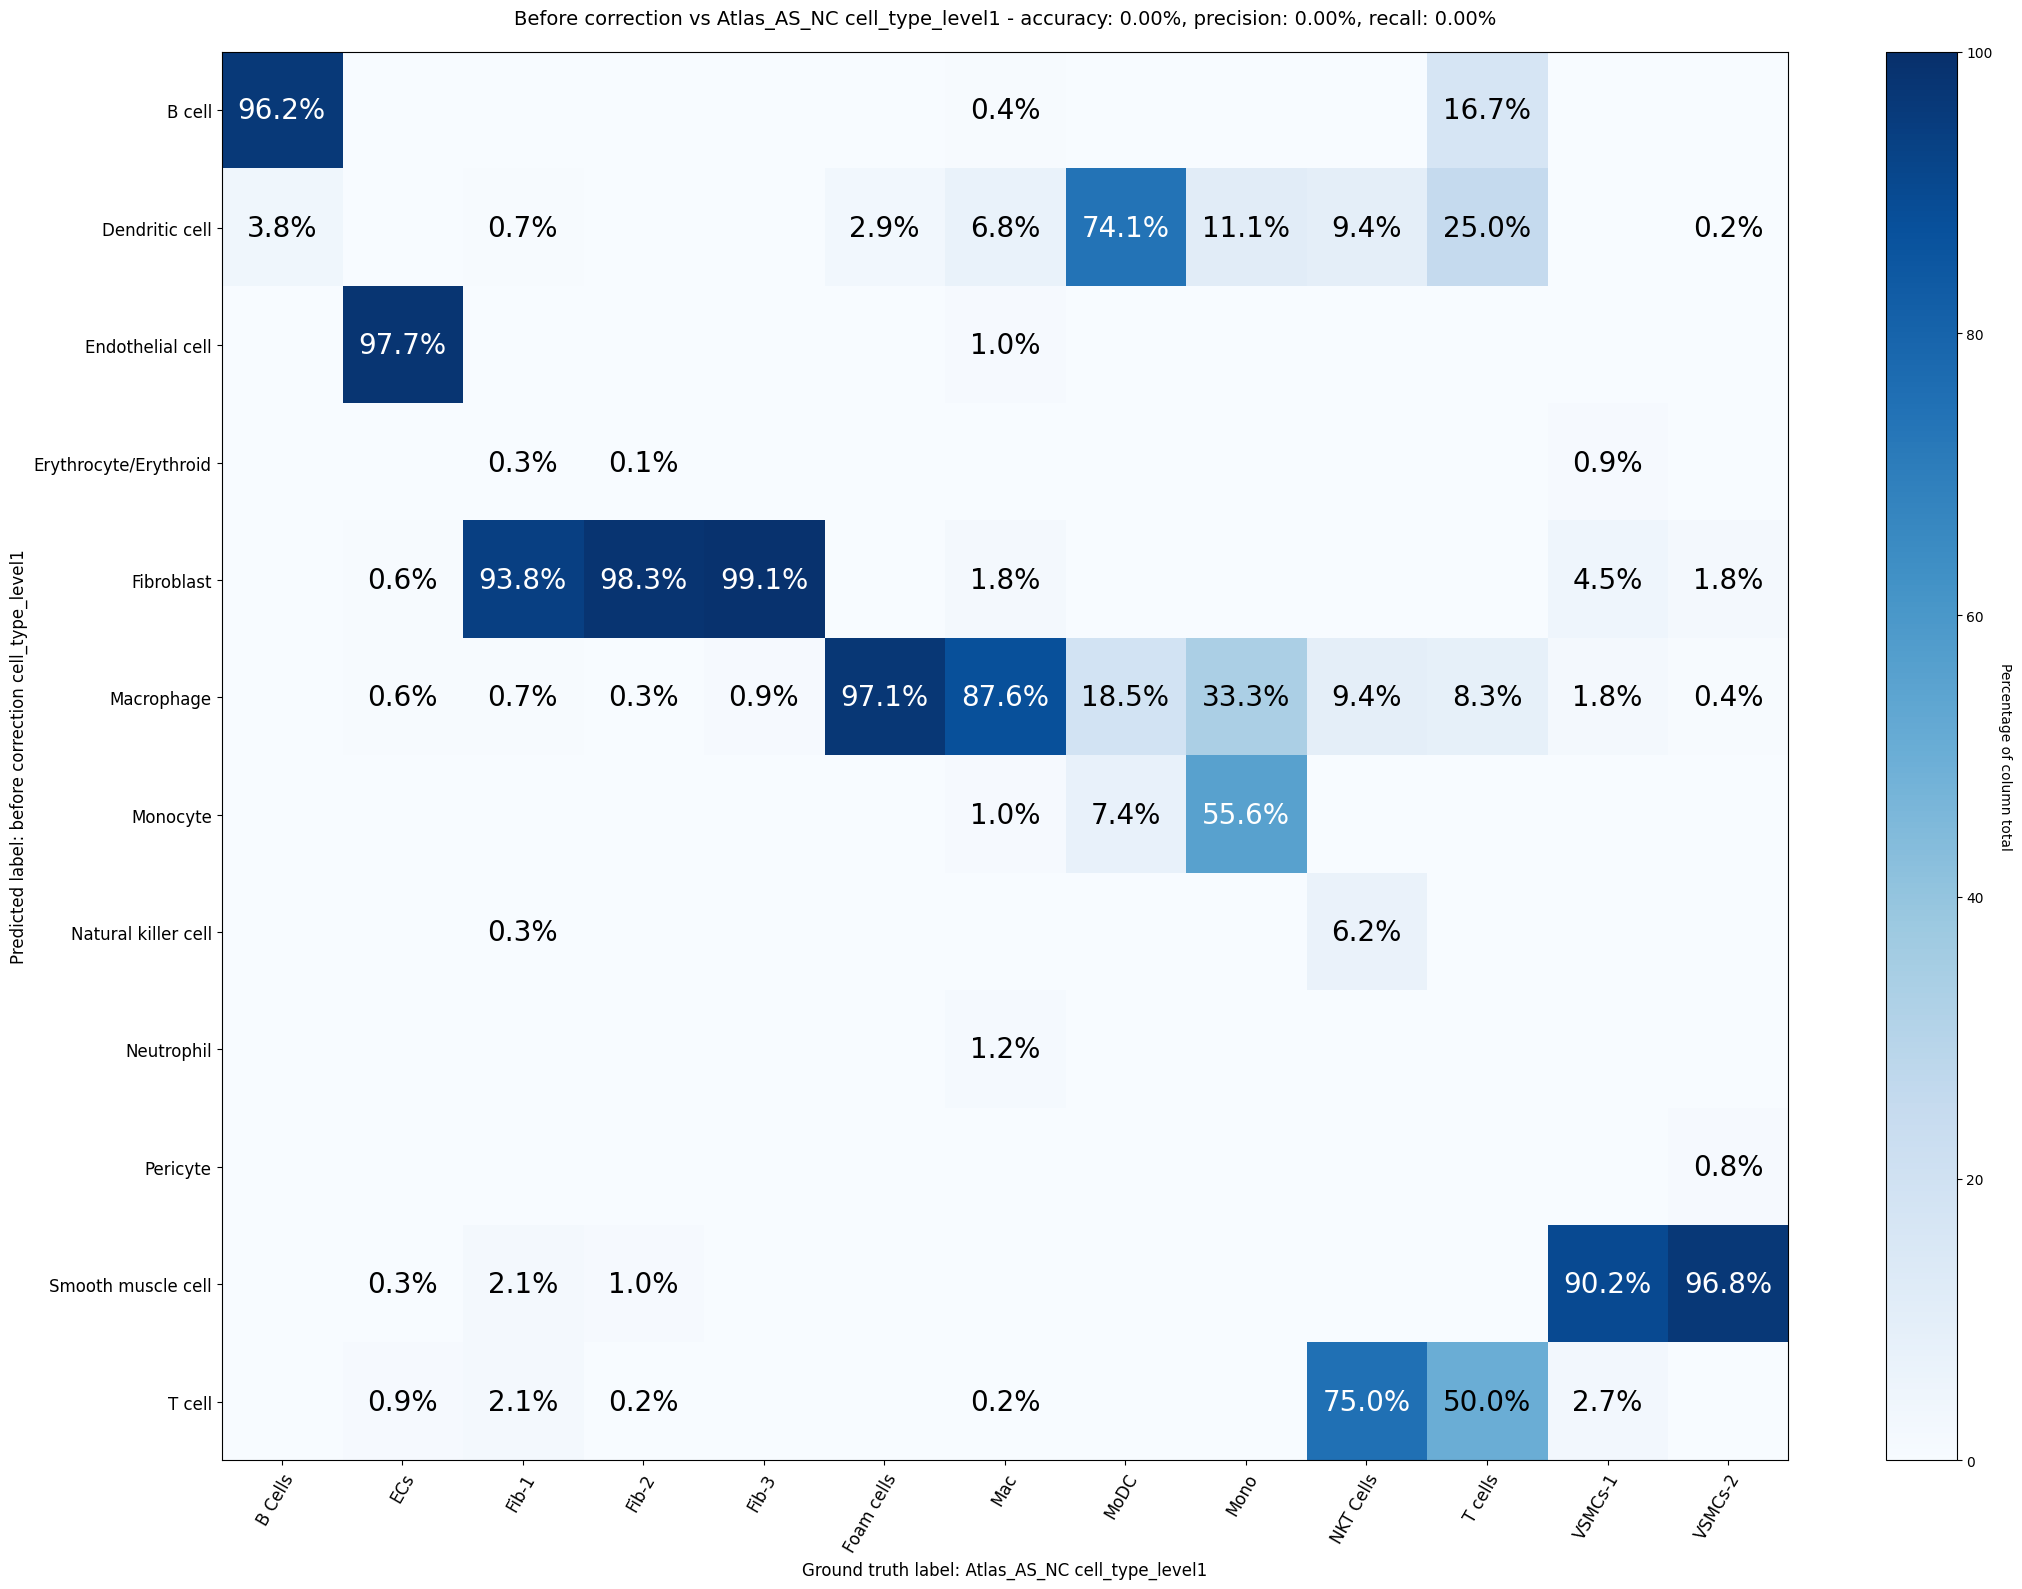


Per-predicted-cell-type precision:
                cell_type  precision
0                  B cell        0.0
1          Dendritic cell        0.0
2        Endothelial cell        0.0
3   Erythrocyte/Erythroid        0.0
4              Fibroblast        0.0
5              Macrophage        0.0
6                Monocyte        0.0
7     Natural killer cell        0.0
8              Neutrophil        0.0
9                Pericyte        0.0
10     Smooth muscle cell        0.0
11                 T cell        0.0

Per-ground-truth-cell-type recall:
     cell_type  recall
0      B Cells     0.0
1          ECs     0.0
2        Fib-1     0.0
3        Fib-2     0.0
4        Fib-3     0.0
5   Foam cells     0.0
6          Mac     0.0
7         MoDC     0.0
8         Mono     0.0
9    NKT Cells     0.0
10     T cells     0.0
11     VSMCs-1     0.0
12     VSMCs-2     0.0


In [27]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


obs_before=adata.obs[["cell_type_level1_corrected"]].copy()
obs_before.index=adata.obs_names.copy()
obs_ref=adata_truth.obs[["ground_truth"]].copy()
obs_ref.index=adata_truth.obs_names.copy()

adata.file.close()

# obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

# print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
# print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_corrected"].astype(str),
    "gt":obs_ref.loc[common_indices,"ground_truth"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

去除指定细胞类型后共有 564966 个细胞
共同匹配到 2908 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B Cells', 'ECs', 'Fib-1', 'Fib-2', 'Fib-3', 'Foam cells', 'Mac', 'MoDC', 'Mono', 'NKT Cells', 'T cells', 'VSMCs-1', 'VSMCs-2']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Erythrocyte/Erythroid', 'Fibroblast', 'Macrophage', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Pericyte', 'Smooth muscle cell', 'T cell']

Accuracy: 0.0000
Weighted precision: 0.0000
Weighted recall: 0.0000

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


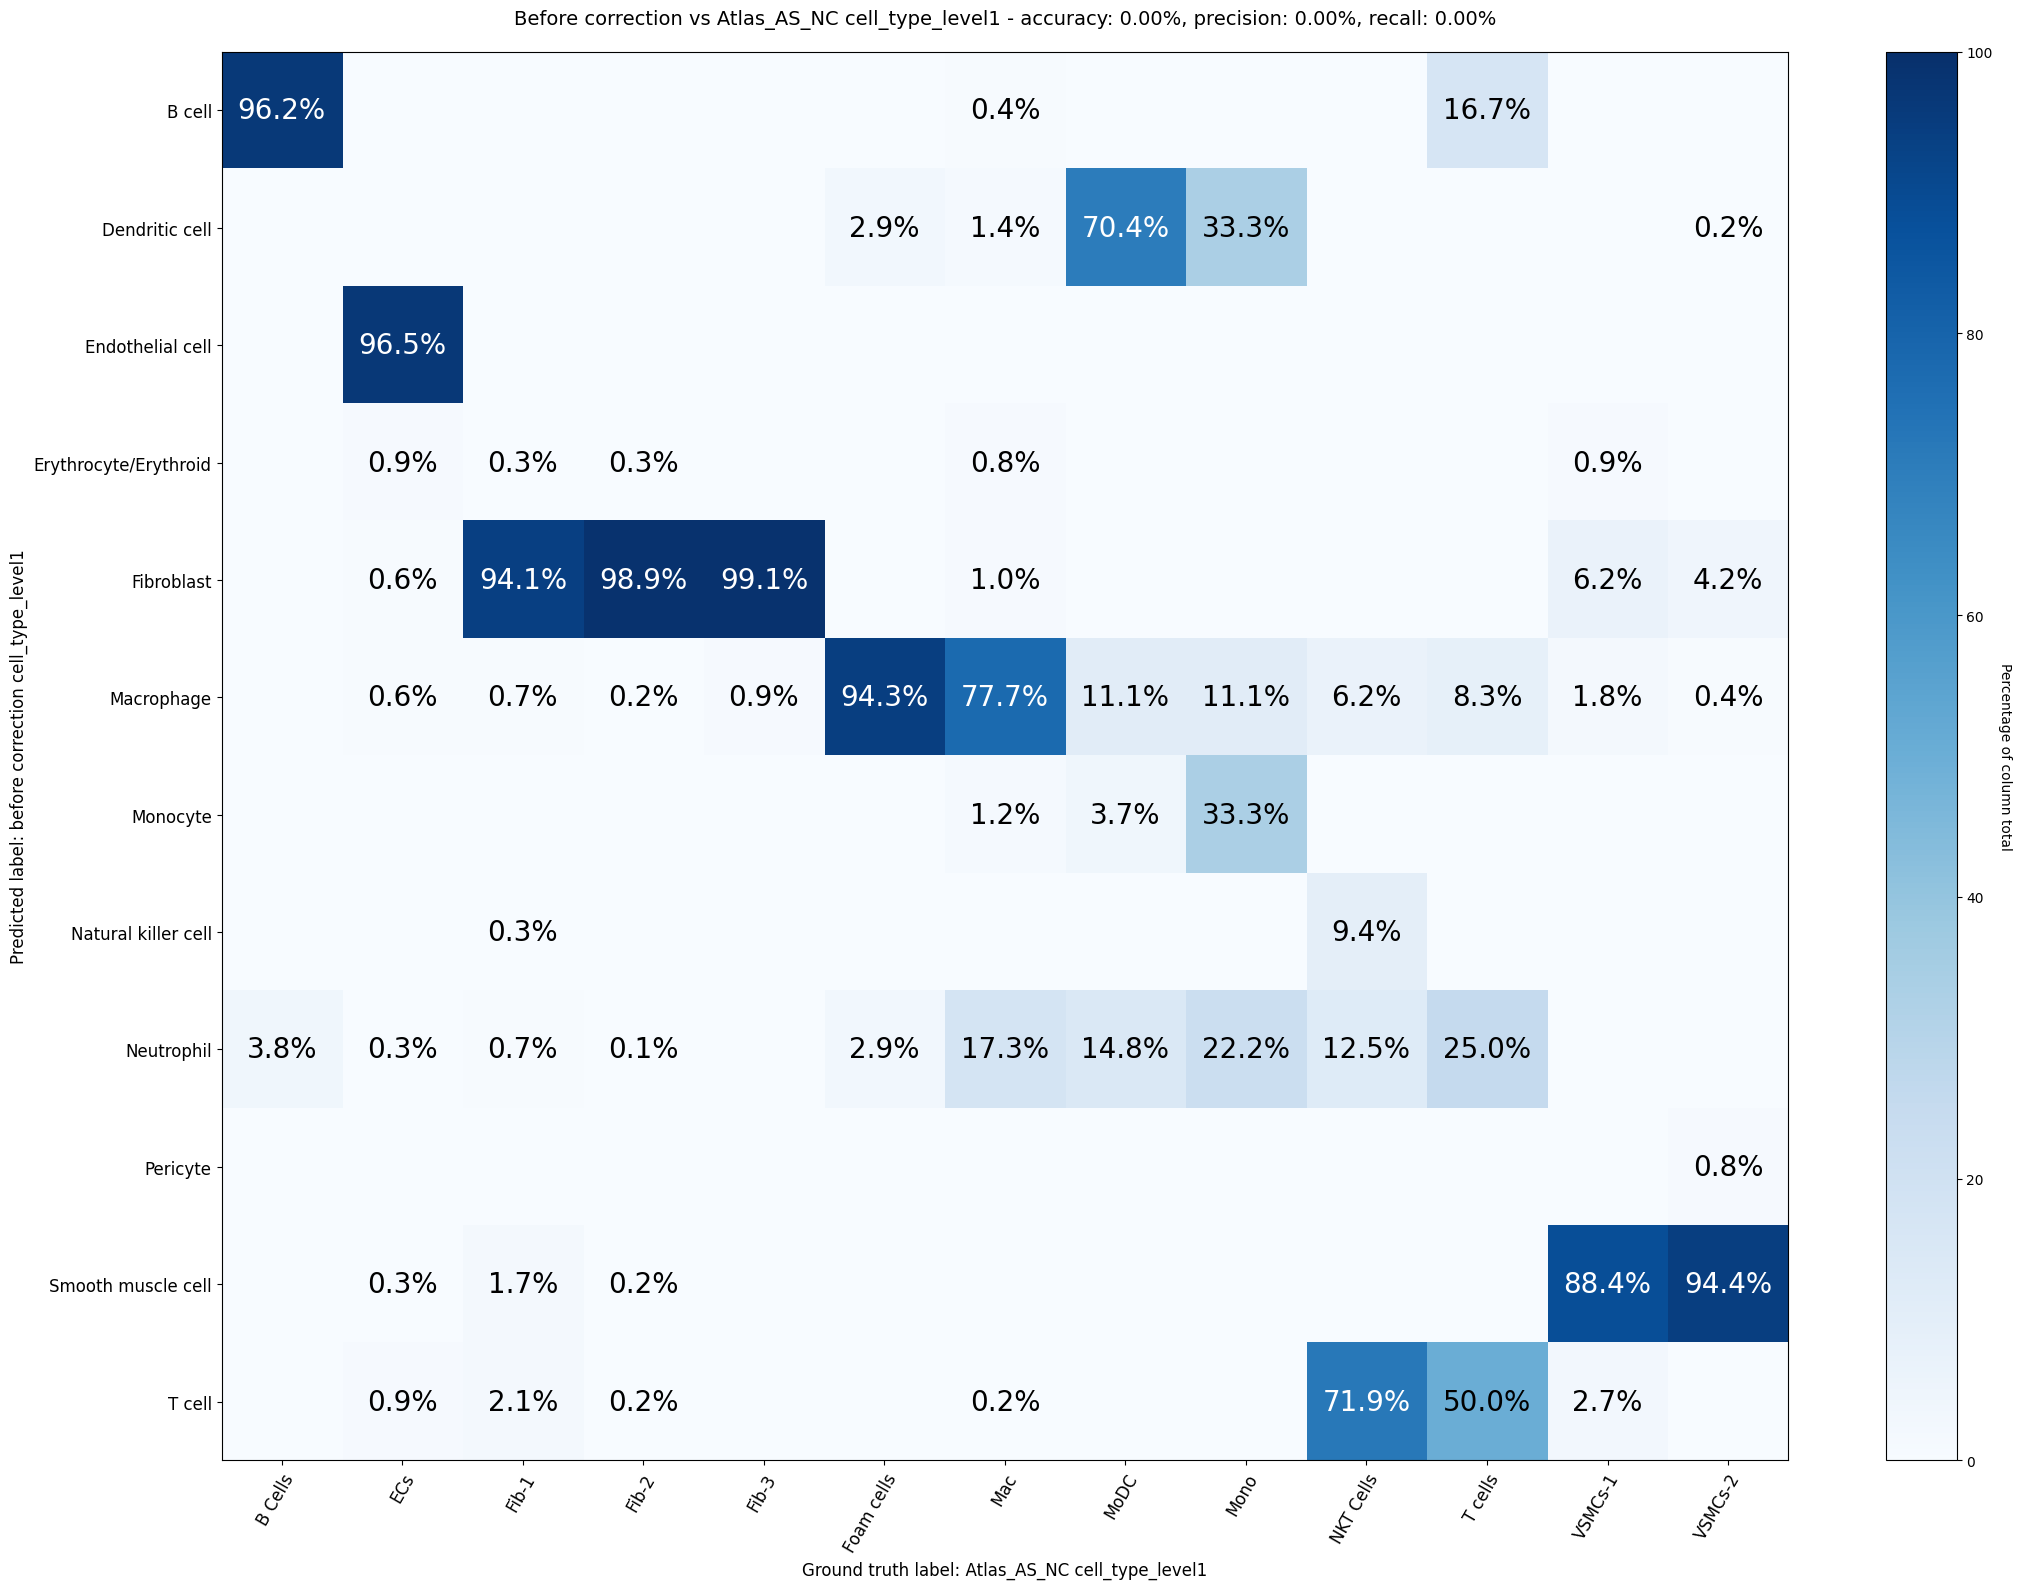


Per-predicted-cell-type precision:
                cell_type  precision
0                  B cell        0.0
1          Dendritic cell        0.0
2        Endothelial cell        0.0
3   Erythrocyte/Erythroid        0.0
4              Fibroblast        0.0
5              Macrophage        0.0
6                Monocyte        0.0
7     Natural killer cell        0.0
8              Neutrophil        0.0
9                Pericyte        0.0
10     Smooth muscle cell        0.0
11                 T cell        0.0

Per-ground-truth-cell-type recall:
     cell_type  recall
0      B Cells     0.0
1          ECs     0.0
2        Fib-1     0.0
3        Fib-2     0.0
4        Fib-3     0.0
5   Foam cells     0.0
6          Mac     0.0
7         MoDC     0.0
8         Mono     0.0
9    NKT Cells     0.0
10     T cells     0.0
11     VSMCs-1     0.0
12     VSMCs-2     0.0


In [9]:
###校正前
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


obs_before=adata.obs[["cell_type_level1"]].copy()
obs_before.index=adata.obs_names.copy()
obs_ref=adata_truth.obs[["ground_truth"]].copy()
obs_ref.index=adata_truth.obs_names.copy()

adata.file.close()

# obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

# print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
# print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1"].astype(str),
    "gt":obs_ref.loc[common_indices,"ground_truth"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)